In [ ]:
from pathlib import Path
from copy import deepcopy
import json
import re
import glob

import ijson
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from preprocess import (is_error_related_feature,
                        place_series,
                        preprocess_node_features,
                        build_edge_index,
                        inspect_edge_features,
                        preprocess_edge_features,
                        make_json_serializable,
                        preprocess_chronograph,
                        fit_robust_scaler,
                        forward_fill)

import matplotlib.pyplot as plt

In [ ]:
import ijson
import numpy as np
from pathlib import Path


def preprocess_anomaly_labels(
    node_json_path: Path,
    node_ids,
    num_timesteps,
    cache_path=None,
):
    """
    Извлекает anomaly_labels из node_features.json.

    Parameters
    ----------
    node_json_path:
        Путь к node_features.json.

    node_ids:
        Порядок узлов, использованный при preprocessing node_raw.
        Обычно:
            metadata["node_ids"]

    num_timesteps:
        T — число временных точек node_raw.

    cache_path:
        Если задан, сохраняет результат в .npy.

    Returns
    -------
    labels:
        np.ndarray shape [T, N]

        labels[t, n] == 1:
            timestep t размечен как anomaly для node n.
    """

    node_to_idx = {
        str(node_id): idx
        for idx, node_id in enumerate(node_ids)
    }

    N = len(node_ids)
    T = num_timesteps

    labels = np.zeros(
        (T, N),
        dtype=np.uint8,
    )

    labeled_nodes = 0

    with open(node_json_path, "rb") as f:
        iterator = ijson.kvitems(f, "")

        for node_id, node_data in iterator:
            node_id = str(node_id)

            node_idx = node_to_idx.get(node_id)

            if node_idx is None:
                continue

            if "anomaly_labels" not in node_data:
                continue

            node_labels = np.asarray(
                node_data["anomaly_labels"],
                dtype=np.uint8,
            )

            if len(node_labels) != T:
                raise ValueError(
                    f"Node {node_id}: "
                    f"anomaly_labels length={len(node_labels)}, "
                    f"expected T={T}"
                )

            labels[:, node_idx] = node_labels

            if node_labels.any():
                labeled_nodes += 1

    print("labels shape:", labels.shape)
    print("anomalous points:", labels.sum())
    print("nodes with anomalies:", labeled_nodes)

    if cache_path is not None:
        np.save(
            cache_path,
            labels
        )

        print(
            "Saved:",
            cache_path
        )

    return labels

In [ ]:
# Путь до клонированного ChronoGraph.
#
# Ожидается структура:
#
# ChronoGraph/
# └── dataset/
#     ├── edges.csv
#     ├── node_features.json
#     ├── edge_features_part1.json
#     ├── edge_features_part2.json
#     └── edge_features_part3.json

ROOT = Path("E:\ChronoGraph")
DATA_DIR = ROOT / "dataset"

CACHE_DIR = Path("./chronograph_cache")
CACHE_DIR.mkdir(exist_ok=True, parents=True)

EDGES_PATH = DATA_DIR / "edges.csv"
NODE_FEATURES_PATH = DATA_DIR / "node_features.json"

EDGE_FEATURE_PATHS = sorted(
    DATA_DIR.glob("edge_features_part*.json")
)

print("Edges:", EDGES_PATH)
print("Nodes:", NODE_FEATURES_PATH)
print("Edge feature files:", EDGE_FEATURE_PATHS)

Edges: E:\ChronoGraph\dataset\edges.csv
Nodes: E:\ChronoGraph\dataset\node_features.json
Edge feature files: [WindowsPath('E:/ChronoGraph/dataset/edge_features_part1.json'), WindowsPath('E:/ChronoGraph/dataset/edge_features_part2.json'), WindowsPath('E:/ChronoGraph/dataset/edge_features_part3.json')]


In [ ]:
example_edge, all_edge_features = inspect_edge_features(
    EDGE_FEATURE_PATHS[0]
)

print("Example edge:", example_edge)

print("\nAll edge features:")
for feature in all_edge_features:
    print(" ", feature)

kept_edge_features = [
    feature
    for feature in all_edge_features
    if not is_error_related_feature(feature)
]

excluded_edge_features = [
    feature
    for feature in all_edge_features
    if is_error_related_feature(feature)
]

print("\nKEPT:")
for feature in kept_edge_features:
    print(" ", feature)

print("\nEXCLUDED:")
for feature in excluded_edge_features:
    print(" ", feature)

Example edge: service410->service103

All edge features:
  requests_total
  rc_2xx:requests_total
  rc_3xx:requests_total
  rc_4xx:requests_total
  rc_5xx:requests_total
  p50:requests_duration
  p90:requests_duration
  p99:requests_duration

KEPT:
  requests_total
  rc_2xx:requests_total
  rc_3xx:requests_total
  p50:requests_duration
  p90:requests_duration
  p99:requests_duration

EXCLUDED:
  rc_4xx:requests_total
  rc_5xx:requests_total


In [ ]:
metadata = preprocess_chronograph(
    DATA_DIR,
    CACHE_DIR,
    force=False,
)

Using cached preprocessing.


In [ ]:
node_raw = np.load(
    CACHE_DIR / "node_raw.npy"
)

edge_raw = np.load(
    CACHE_DIR / "edge_raw.npy"
)

edge_index_np = np.load(
    CACHE_DIR / "edge_index.npy"
)

with open(CACHE_DIR / "metadata.json") as f:
    metadata = json.load(f)

print("node_raw:", node_raw.shape)
print("edge_raw:", edge_raw.shape)
print("edge_index:", edge_index_np.shape)

print()
print("Node features:")
print(metadata["node_features"])

print()
print("Used edge features:")
print(metadata["edge_features"])

node_raw: (8005, 708, 5)
edge_raw: (8005, 1529, 6)
edge_index: (2, 1529)

Node features:
['container_memory_usage_bytes', 'container_memory_working_set_bytes', 'container_network_receive_bytes_total', 'container_network_transmit_bytes_total', 'cpu_usage']

Used edge features:
['requests_total', 'rc_2xx:requests_total', 'rc_3xx:requests_total', 'p50:requests_duration', 'p90:requests_duration', 'p99:requests_duration']


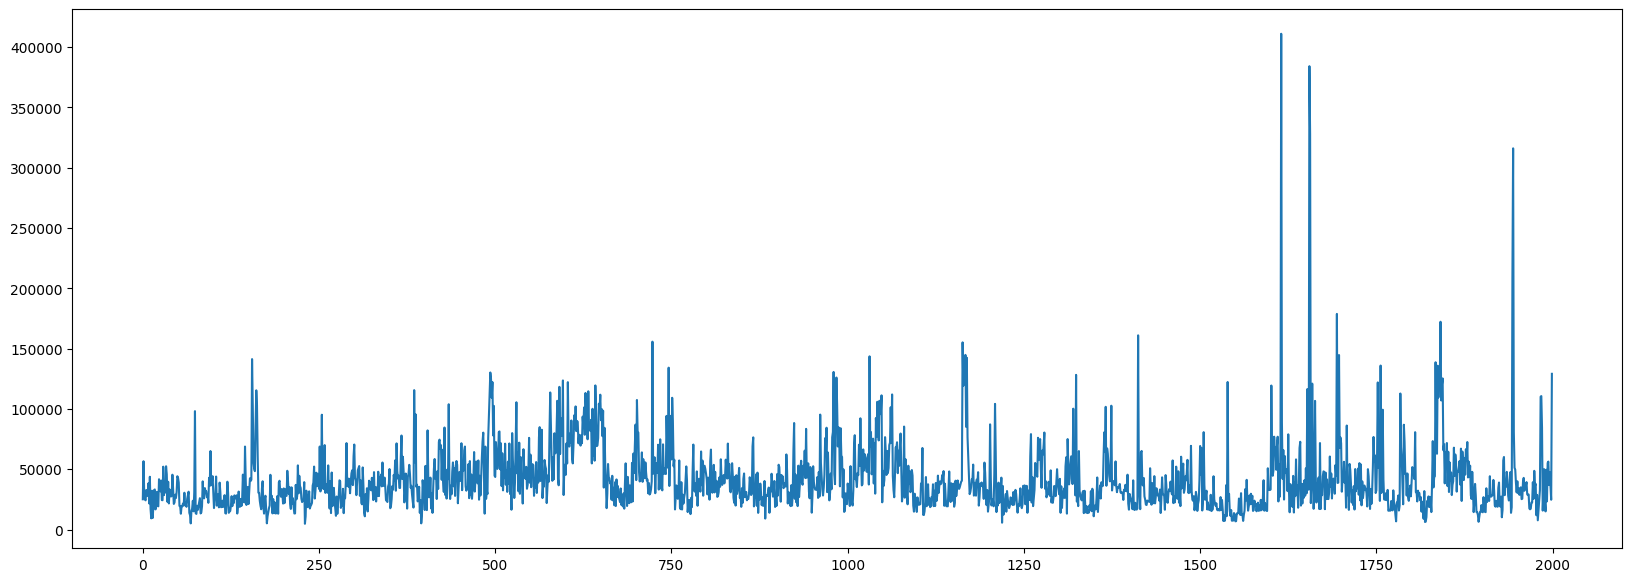

In [ ]:
plt.figure(figsize=(20,7))
plt.plot(node_raw[:,0,2][:2000])

In [ ]:
ANOMALY_CACHE = (
    CACHE_DIR / "anomaly_labels.npy"
)

anomaly_labels = preprocess_anomaly_labels(
    node_json_path=DATA_DIR / "node_features.json",

    node_ids=metadata["node_ids"],

    num_timesteps=node_raw.shape[0],

    cache_path=ANOMALY_CACHE,
)

labels shape: (8005, 708)
anomalous points: 2302
nodes with anomalies: 16
Saved: chronograph_cache\anomaly_labels.npy


In [ ]:
anomaly_labels = np.load(
    CACHE_DIR / "anomaly_labels.npy"
)

In [ ]:
def binary_to_segments(labels):
    """
    Превращает бинарный массив [T]
    в список contiguous anomaly intervals.

    Returns
    -------
    list[tuple]:
        [(start, end), ...]

    end включительно.
    """

    labels = np.asarray(
        labels,
        dtype=bool,
    )

    padded = np.pad(
        labels.astype(np.int8),
        (1, 1),
        constant_values=0,
    )

    diff = np.diff(padded)

    starts = np.where(
        diff == 1
    )[0]

    ends = (
        np.where(
            diff == -1
        )[0]
        - 1
    )

    return list(
        zip(
            starts.tolist(),
            ends.tolist(),
        )
    )

In [ ]:
def collect_anomaly_segments(
    anomaly_labels,
    node_ids=None,
):
    """
    Возвращает таблицу всех anomaly segments
    по всем узлам.
    """

    rows = []

    T, N = anomaly_labels.shape

    if node_ids is None:
        node_ids = list(
            range(N)
        )

    for node_idx in range(N):

        segments = binary_to_segments(
            anomaly_labels[
                :, node_idx
            ]
        )

        for segment_idx, (
            start,
            end,
        ) in enumerate(segments):

            rows.append({
                "node_idx": node_idx,
                "node_id": node_ids[node_idx],

                "segment_idx": segment_idx,

                "start": start,
                "end": end,

                "length": (
                    end - start + 1
                ),
            })

    return pd.DataFrame(rows)

In [ ]:
anomaly_segments = collect_anomaly_segments(
    anomaly_labels,
    node_ids=metadata["node_ids"],
)

anomaly_segments

,node_idx,node_id,segment_idx,start,end,length
0,101,service102,0,3622,3765,144
1,171,service172,0,3665,3808,144
2,237,service238,0,1555,1698,144
3,263,service264,0,4912,5055,144
4,270,service271,0,5920,6063,144
5,299,service300,0,217,360,144
6,399,service400,0,2237,2380,144
7,428,service429,0,6202,6345,144
8,439,service440,0,6921,7064,144
9,503,service504,0,7600,7743,144


In [ ]:
import pandas as pd


def make_time_axis(
    time_steps,
    unit=None,
):
    """
    Если timestamps числовые Unix timestamps,
    можно указать unit='s', 'ms', etc.

    Если unit=None, возвращаем исходные steps.
    """

    if unit is None:
        return np.asarray(
            time_steps
        )

    return pd.to_datetime(
        time_steps,
        unit=unit,
    )

In [ ]:
time_axis = make_time_axis(
    metadata["time_steps"],
    unit=None,
)

In [ ]:
import matplotlib.pyplot as plt


def plot_anomaly_segment(
    node_raw,
    anomaly_labels,
    node_idx,
    segment_idx=0,
    feature_names=None,
    time_steps=None,
    padding_before=48,
    padding_after=48,
    selected_features=None,
    figsize_per_feature=3.0,
):
    """
    Визуализация одного anomaly segment для одного node.

    Parameters
    ----------
    node_raw:
        [T, N, F]

        Желательно исходные ненормализованные данные.

    anomaly_labels:
        [T, N]

    node_idx:
        Индекс node.

    segment_idx:
        Какой anomaly segment данного node показать.

    feature_names:
        metadata["node_features"]

    time_steps:
        metadata["time_steps"] либо преобразованный datetime axis.

    padding_before:
        Сколько точек показать до anomaly.

    padding_after:
        Сколько точек показать после anomaly.

    selected_features:
        None -> все features.

        Можно:
            [0, 1, 3]

        или:
            ["cpu_usage", ...]
    """

    T, N, F = node_raw.shape

    node_labels = anomaly_labels[
        :, node_idx
    ]

    segments = binary_to_segments(
        node_labels
    )

    if len(segments) == 0:
        raise ValueError(
            f"Node {node_idx} "
            "не содержит размеченных anomalies."
        )

    if not (
        0 <= segment_idx < len(segments)
    ):
        raise ValueError(
            f"segment_idx={segment_idx}, "
            f"но у node только {len(segments)} segments."
        )

    anomaly_start, anomaly_end = (
        segments[segment_idx]
    )

    plot_start = max(
        0,
        anomaly_start - padding_before,
    )

    plot_end = min(
        T,
        anomaly_end + padding_after + 1,
    )

    # -----------------------------------
    # Features
    # -----------------------------------

    if feature_names is None:
        feature_names = [
            f"feature_{i}"
            for i in range(F)
        ]

    if selected_features is None:

        selected_indices = list(
            range(F)
        )

    else:

        selected_indices = []

        for feature in selected_features:

            if isinstance(
                feature,
                (int, np.integer)
            ):
                selected_indices.append(
                    int(feature)
                )

            else:
                selected_indices.append(
                    feature_names.index(
                        feature
                    )
                )

    # -----------------------------------
    # X axis
    # -----------------------------------

    indices = np.arange(
        plot_start,
        plot_end,
    )

    if time_steps is None:
        x = indices

        anomaly_x_start = (
            anomaly_start
        )

        anomaly_x_end = (
            anomaly_end
        )

    else:
        x = np.asarray(
            time_steps
        )[indices]

        anomaly_x_start = (
            time_steps[
                anomaly_start
            ]
        )

        anomaly_x_end = (
            time_steps[
                anomaly_end
            ]
        )

    # -----------------------------------
    # Plot
    # -----------------------------------

    n_plots = len(
        selected_indices
    )

    fig, axes = plt.subplots(
        n_plots,
        1,
        figsize=(
            14,
            figsize_per_feature
            * n_plots,
        ),
        sharex=True,
    )

    if n_plots == 1:
        axes = [axes]

    for ax, feature_idx in zip(
        axes,
        selected_indices,
    ):

        values = node_raw[
            plot_start:plot_end,
            node_idx,
            feature_idx,
        ]

        ax.plot(
            x,
            values,
            linewidth=1.5,
            label="Telemetry",
        )

        # Размеченная anomaly область.
        ax.axvspan(
            anomaly_x_start,
            anomaly_x_end,
            alpha=0.20,
            label="Anomaly",
        )

        ax.axvline(
            anomaly_x_start,
            linestyle="--",
            alpha=0.7,
        )

        ax.axvline(
            anomaly_x_end,
            linestyle="--",
            alpha=0.7,
        )

        ax.set_ylabel(
            feature_names[
                feature_idx
            ]
        )

        ax.grid(
            alpha=0.25
        )

        ax.legend(
            loc="upper right"
        )

    axes[-1].set_xlabel(
        "Time"
    )

    fig.suptitle(
        f"Node {node_idx} | "
        f"anomaly #{segment_idx} | "
        f"[{anomaly_start}, {anomaly_end}]",
        fontsize=14,
    )

    plt.tight_layout()

    return fig

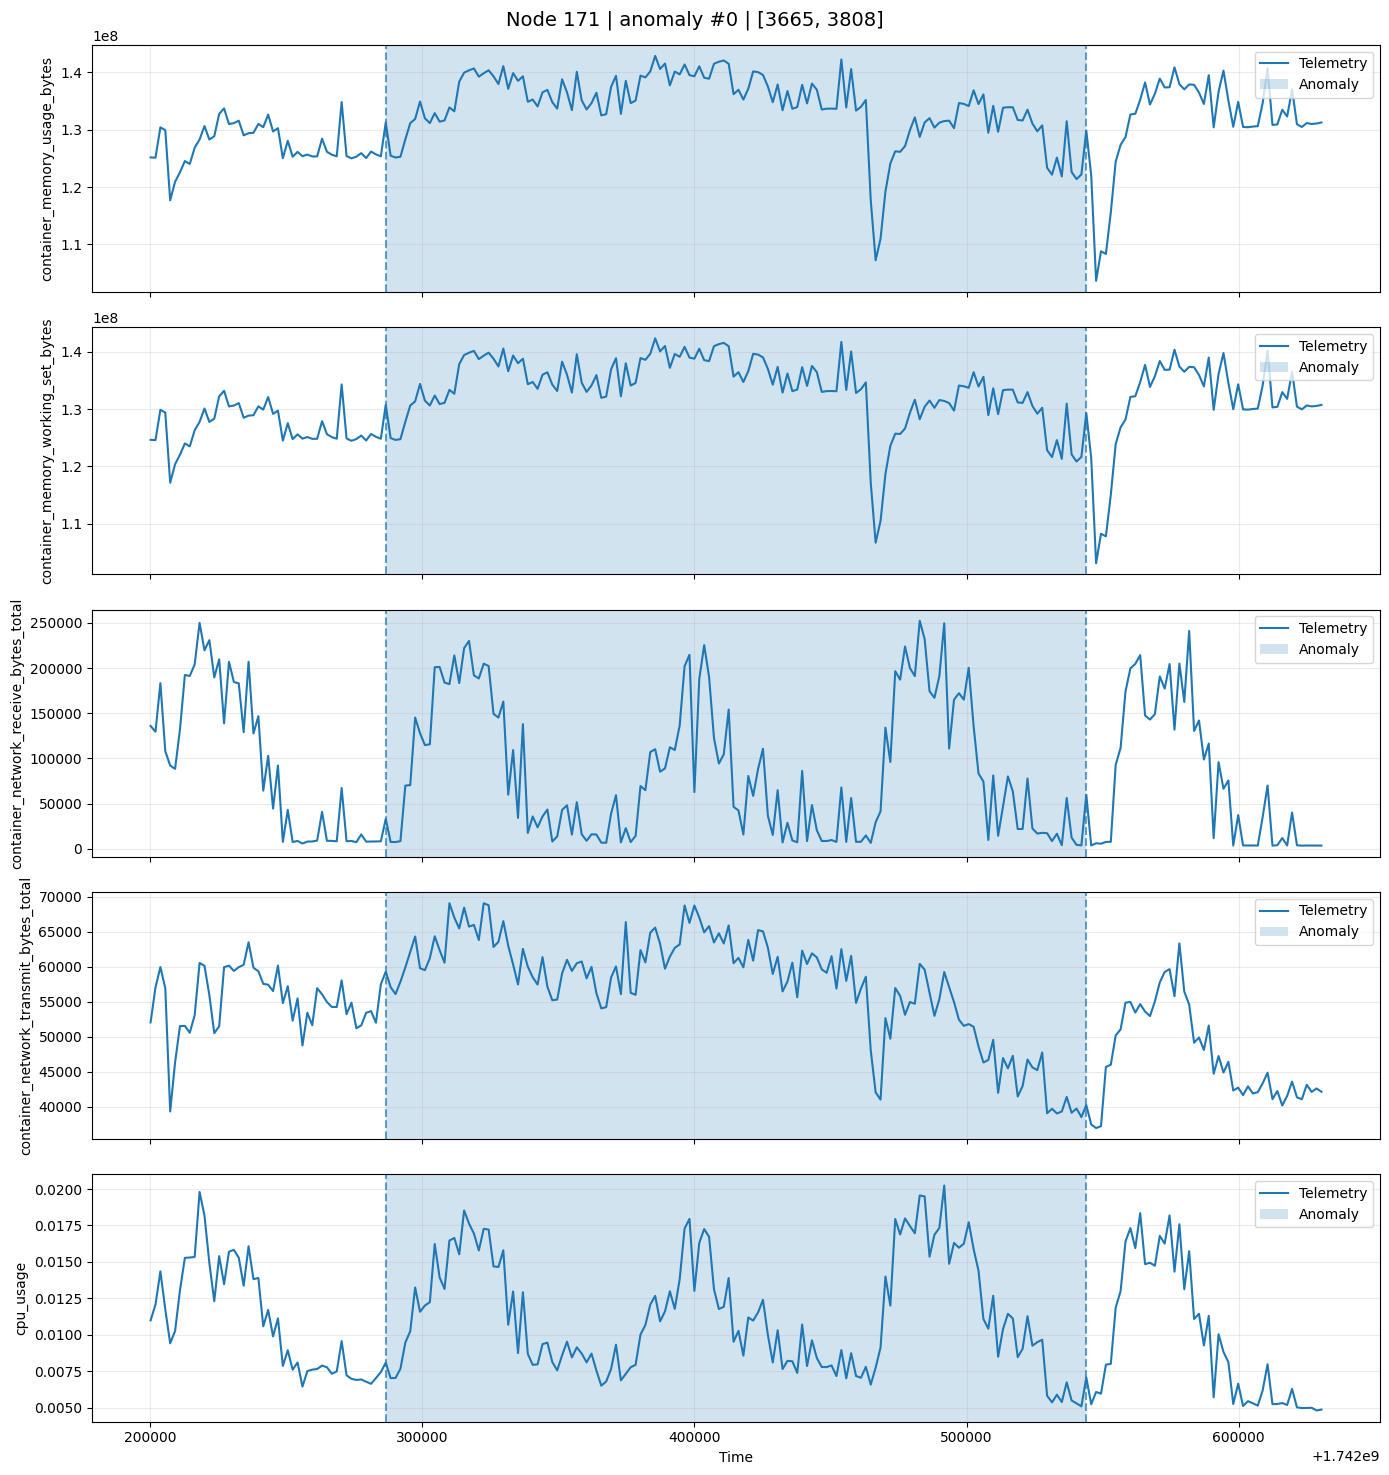

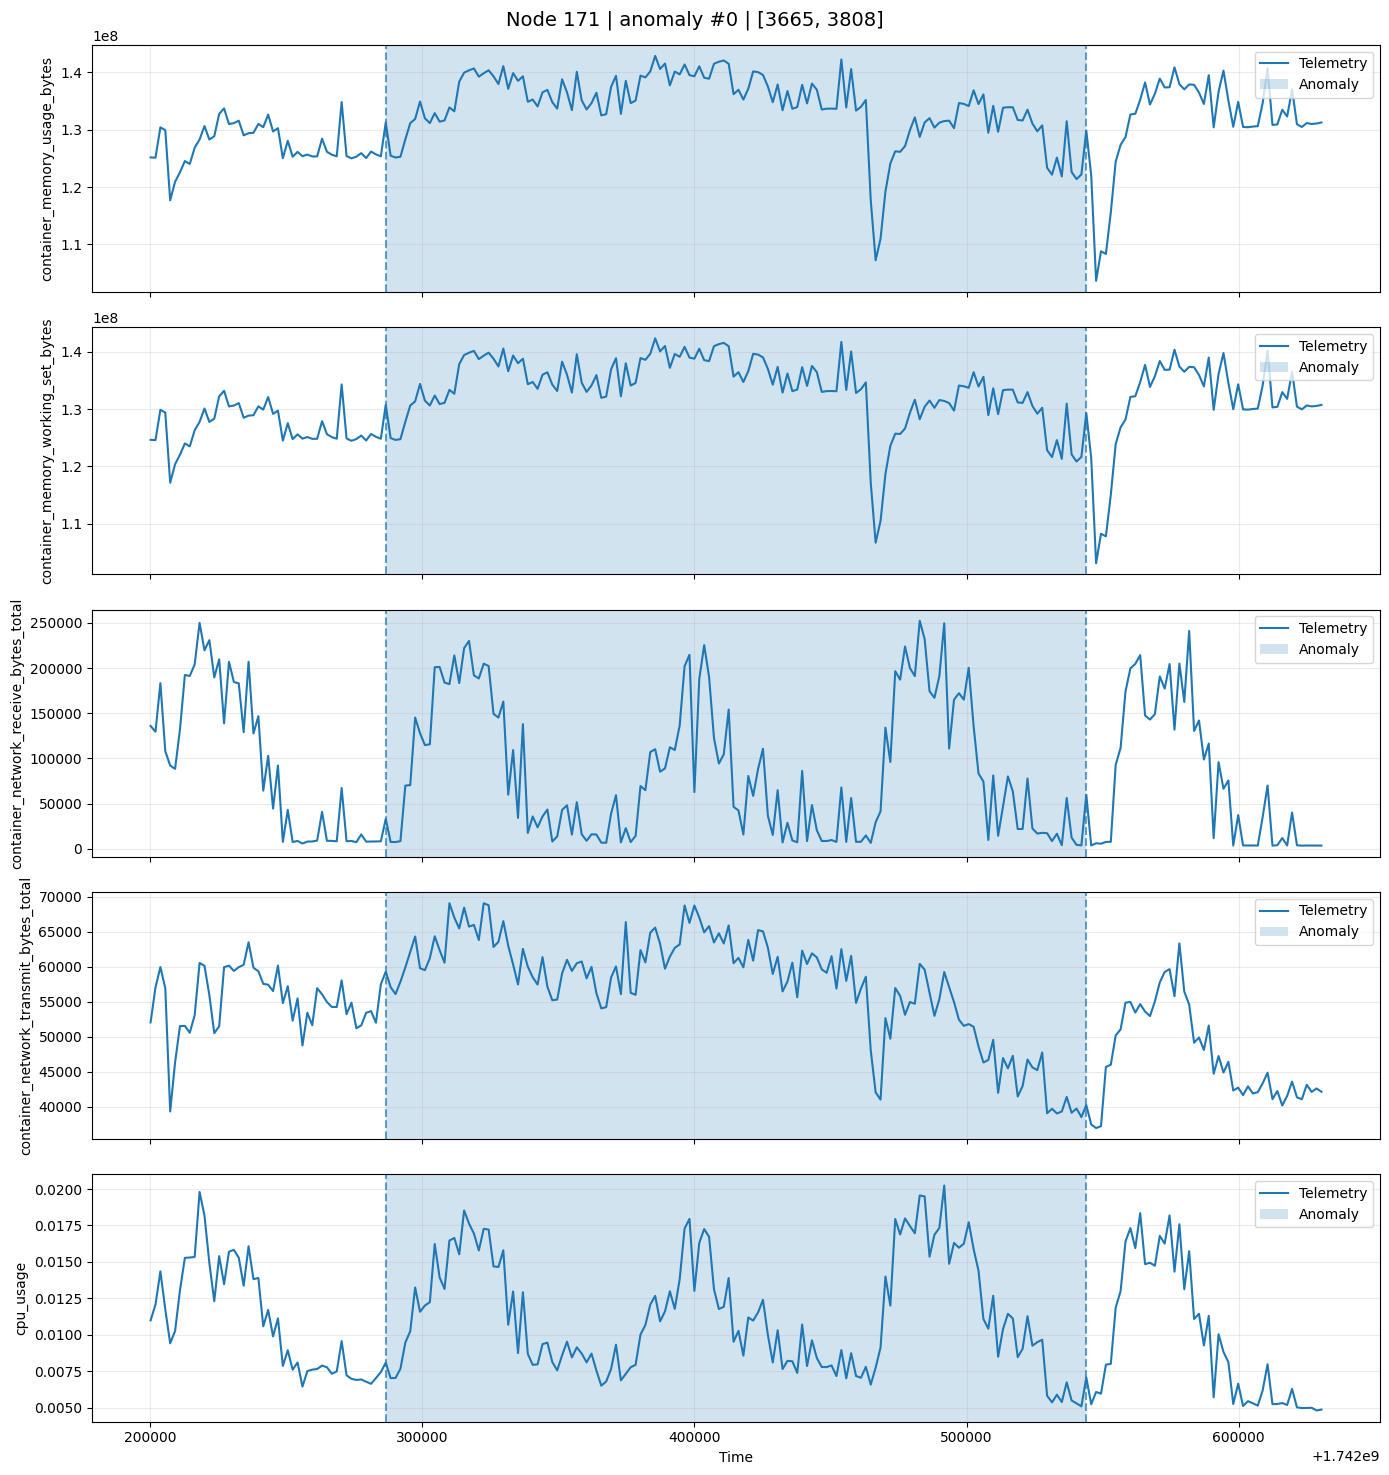

In [ ]:
first = anomaly_segments.iloc[2]

NODE_IDX = int(
    first["node_idx"]
)

SEGMENT_IDX = int(
    first["segment_idx"]
)

plot_anomaly_segment(
    node_raw=node_raw,

    anomaly_labels=anomaly_labels,

    node_idx=NODE_IDX,
    segment_idx=SEGMENT_IDX,

    feature_names=metadata[
        "node_features"
    ],

    time_steps=metadata.get(
        "time_steps"
    ),

    # 48 * 30 минут = 24 часа
    padding_before=48,
    padding_after=48,
)

In [17]:
T = node_raw.shape[0]

train_end = int(T * 0.60)
val_end = int(T * 0.80)

print("T:", T)
print("train:", 0, train_end)
print("val:", train_end, val_end)
print("test:", val_end, T)

T: 8005
train: 0 4803
val: 4803 6404
test: 6404 8005


In [18]:
node_median, node_scale = fit_robust_scaler(
    node_raw,
    train_end
)

node_filled = forward_fill(
    node_raw,
    node_median
)

node_x = (
    node_filled - node_median[None, :, :]
) / node_scale[None, :, :]

node_x = node_x.astype(np.float32)

print(node_x.shape)
print("NaNs:", np.isnan(node_x).sum())

Forward filling:   0%|          | 0/3540 [00:00<?, ?it/s]

(8005, 708, 5)
NaNs: 0


In [19]:
edge_filled = np.nan_to_num(
    edge_raw,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
).astype(np.float32)

In [20]:
edge_median, edge_scale = fit_robust_scaler(
    edge_filled,
    train_end
)

edge_x = (
    edge_filled - edge_median[None, :, :]
) / edge_scale[None, :, :]

edge_x = edge_x.astype(np.float32)

print(edge_x.shape)
print("NaNs:", np.isnan(edge_x).sum())

(8005, 1529, 6)
NaNs: 0


In [21]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

DEVICE

device(type='cuda')

In [22]:
NUM_NODE_FEATURES = node_x.shape[-1]
NUM_EDGE_FEATURES = edge_x.shape[-1]


In [23]:
# criterion = nn.SmoothL1Loss(
#     beta=1.0
# )
# criterion = nn.HuberLoss()
criterion = nn.MSELoss()

In [24]:
def train_one_epoch(
    model,
    loader,
    edge_index,
    optimizer,
    criterion,
    device,
    grad_clip=1.0,
):
    model.train()

    total_loss = 0.0

    progress = tqdm(
        loader,
        leave=False
    )

    for batch in progress:

        node_seq = batch[
            "node_seq"
        ].to(
            device,
            non_blocking=True
        )

        edge_attr = batch[
            "edge_attr"
        ].to(
            device,
            non_blocking=True
        )

        target = batch[
            "target"
        ].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        prediction = model(
            node_seq=node_seq,
            edge_attr=edge_attr,
            edge_index=edge_index,
        )

        loss = criterion(
            prediction,
            target
        )

        loss.backward()

        if grad_clip is not None:
            nn.utils.clip_grad_norm_(
                model.parameters(),
                grad_clip
            )

        optimizer.step()

        total_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss / len(loader)
    )
    


In [25]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    edge_index,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    total_abs_error = 0.0
    total_sq_error = 0.0
    total_elements = 0
    total_batches = 0

    for batch in loader:

        node_seq = batch[
            "node_seq"
        ].to(
            device,
            non_blocking=True
        )

        edge_attr = batch[
            "edge_attr"
        ].to(
            device,
            non_blocking=True
        )

        target = batch[
            "target"
        ].to(
            device,
            non_blocking=True
        )

        prediction = model(
            node_seq,
            edge_attr,
            edge_index,
        )

        loss = criterion(
            prediction,
            target
        )

        error = (
            prediction - target
        )

        total_loss += loss.item()

        total_abs_error += (
            error.abs().sum().item()
        )

        total_sq_error += (
            error.square().sum().item()
        )

        total_elements += (
            target.numel()
        )

        total_batches += 1

    return {
        "loss": (
            total_loss / total_batches
        ),

        "mae": (
            total_abs_error
            / total_elements
        ),

        "rmse": (
            total_sq_error
            / total_elements
        ) ** 0.5,
    }

In [26]:
def fit(
    model,
    train_loader,
    val_loader,
    edge_index,
    device,
    epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    patience=5,
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    criterion = nn.SmoothL1Loss(
        beta=1.0
    )

    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    history = []

    for epoch in range(
        1,
        epochs + 1
    ):

        train_loss = train_one_epoch(
            model=model,
            loader=train_loader,
            edge_index=edge_index,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            grad_clip=1.0,
        )

        val_metrics = evaluate(
            model=model,
            loader=val_loader,
            edge_index=edge_index,
            criterion=criterion,
            device=device,
        )

        epoch_result = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_mae": val_metrics["mae"],
            "val_rmse": val_metrics["rmse"],
        }

        history.append(
            epoch_result
        )

        print(
            f"Epoch {epoch:03d} | "
            f"train={train_loss:.5f} | "
            f"val={val_metrics['loss']:.5f} | "
            f"MAE={val_metrics['mae']:.5f} | "
            f"RMSE={val_metrics['rmse']:.5f}"
        )

        # ----------------------------
        # Early stopping
        # ----------------------------

        if (
            val_metrics["loss"]
            < best_val_loss
        ):
            best_val_loss = (
                val_metrics["loss"]
            )

            best_state = deepcopy(
                model.state_dict()
            )

            bad_epochs = 0

        else:
            bad_epochs += 1

            if bad_epochs >= patience:
                print(
                    f"Early stopping at "
                    f"epoch {epoch}"
                )
                break

    if best_state is not None:
        model.load_state_dict(
            best_state
        )

    return pd.DataFrame(
        history
    )

In [27]:
class ChronoGraphMultiHorizonDataset(Dataset):
    def __init__(
        self,
        node_x: np.ndarray,
        edge_x: np.ndarray,
        context_length: int,
        horizon: int,
        target_start: int,
        target_end: int,
    ):
        """
        Формирует:

            X[t-L:t] -> X[t:t+H]

        Parameters
        ----------
        node_x:
            [T, N, F_node]

        edge_x:
            [T, E, F_edge]

        context_length:
            L

        horizon:
            H

        target_start:
            первая допустимая target point

        target_end:
            конец split (exclusive)
        """

        self.node_x = node_x
        self.edge_x = edge_x

        self.context_length = context_length
        self.horizon = horizon

        # Последний допустимый start:
        #
        # t + horizon <= target_end
        #
        # следовательно:
        #
        # t <= target_end - horizon

        first_t = max(
            target_start,
            context_length,
        )

        last_t_exclusive = (
            target_end
            - horizon
            + 1
        )

        self.target_times = np.arange(
            first_t,
            last_t_exclusive,
            dtype=np.int64,
        )

    def __len__(self):
        return len(
            self.target_times
        )

    def __getitem__(self, idx):

        t = int(
            self.target_times[idx]
        )

        # --------------------------------
        # История nodes:
        #
        # [t-L, ..., t-1]
        # --------------------------------

        node_seq = self.node_x[
            t - self.context_length:t
        ]

        # --------------------------------
        # Последнее доступное состояние edges
        # --------------------------------

        edge_attr = self.edge_x[
            t - 1
        ]

        # --------------------------------
        # H будущих точек:
        #
        # [t, t+1, ..., t+H-1]
        #
        # [H, N, F]
        # --------------------------------

        target = self.node_x[
            t:t + self.horizon
        ]

        return {
            "node_seq": torch.tensor(
                node_seq,
                dtype=torch.float32,
            ),

            "edge_attr": torch.tensor(
                edge_attr,
                dtype=torch.float32,
            ),

            "target": torch.tensor(
                target,
                dtype=torch.float32,
            ),

            "time_idx": torch.tensor(
                t,
                dtype=torch.long,
            ),
        }

In [28]:
CONTEXT_LENGTH = 336
HORIZON = 336
train_dataset = ChronoGraphMultiHorizonDataset(
    node_x=node_x,
    edge_x=edge_x,

    context_length=CONTEXT_LENGTH,
    horizon=HORIZON,

    target_start=0,
    target_end=train_end,
)

val_dataset = ChronoGraphMultiHorizonDataset(
    node_x=node_x,
    edge_x=edge_x,

    context_length=CONTEXT_LENGTH,
    horizon=HORIZON,

    target_start=train_end,
    target_end=val_end,
)

test_dataset = ChronoGraphMultiHorizonDataset(
    node_x=node_x,
    edge_x=edge_x,

    context_length=CONTEXT_LENGTH,
    horizon=HORIZON,

    target_start=val_end,
    target_end=T,
)

In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

In [30]:
class GraphMessagePassingLayer(nn.Module):
    def __init__(
        self,
        hidden_dim,
        edge_input_dim,
        message_dim,
        dropout=0.1,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.message_dim = message_dim

        self.message_mlp = nn.Sequential(
            nn.Linear(
                2 * hidden_dim + edge_input_dim,
                message_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(
                message_dim,
                message_dim,
            ),
            nn.GELU(),
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(
                hidden_dim + message_dim,
                hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
        )

        self.norm = nn.LayerNorm(
            hidden_dim
        )

    def forward(
        self,
        h,
        edge_attr,
        edge_index,
    ):
        """
        h:
            [B, N, H]

        edge_attr:
            [B, E, F_edge]

        edge_index:
            [2, E]
        """

        B, N, _ = h.shape

        src = edge_index[0]
        dst = edge_index[1]

        h_src = h[:, src, :]
        h_dst = h[:, dst, :]

        message_input = torch.cat(
            [
                h_src,
                h_dst,
                edge_attr,
            ],
            dim=-1,
        )

        messages = self.message_mlp(
            message_input
        )

        aggregated = torch.zeros(
            B,
            N,
            self.message_dim,
            device=h.device,
            dtype=h.dtype,
        )

        aggregated.index_add_(
            dim=1,
            index=dst,
            source=messages,
        )

        degree = torch.bincount(
            dst,
            minlength=N,
        )

        degree = (
            degree
            .clamp_min(1)
            .view(1, N, 1)
            .to(h.dtype)
        )

        aggregated = (
            aggregated / degree
        )

        update = self.update_mlp(
            torch.cat(
                [h, aggregated],
                dim=-1,
            )
        )

        return self.norm(
            h + update
        )

In [31]:
class GraphTemporalMultiHorizonForecaster(nn.Module):
    def __init__(
        self,
        node_input_dim: int,
        edge_input_dim: int,
        horizon: int,
        hidden_dim: int = 64,
        message_dim: int = 64,
        num_graph_layers: int = 1,
        dropout: float = 0.1,
        predict_residual: bool = True,
    ):
        super().__init__()

        self.node_input_dim = (
            node_input_dim
        )

        self.edge_input_dim = (
            edge_input_dim
        )

        self.horizon = horizon
        self.hidden_dim = hidden_dim
        self.message_dim = message_dim

        self.predict_residual = (
            predict_residual
        )

        # ==============================
        # Temporal encoder
        # ==============================

        self.node_gru = nn.GRU(
            input_size=node_input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )

        # ==============================
        # Message function
        # ==============================

        self.message_mlp = nn.Sequential(
            nn.Linear(
                2 * hidden_dim
                + edge_input_dim,
                message_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(
                message_dim,
                message_dim,
            ),
            nn.GELU(),
        )

        # ==============================
        # Node update
        # ==============================

        self.update_mlp = nn.Sequential(
            nn.Linear(
                hidden_dim
                + message_dim,
                hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
        )

        self.node_norm = nn.LayerNorm(
            hidden_dim
        )
        
        self.graph_layers = nn.ModuleList([
            GraphMessagePassingLayer(
                hidden_dim=hidden_dim,
                edge_input_dim=edge_input_dim,
                message_dim=message_dim,
                dropout=dropout,
            )
            for _ in range(num_graph_layers)
        ])

        # ==============================
        # Multi-horizon decoder
        #
        # H -> horizon * feature_dim
        # ==============================

        self.decoder = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim,
                horizon * node_input_dim,
            ),
        )

    def encode_nodes(
        self,
        node_seq,
    ):

        B, L, N, F = (
            node_seq.shape
        )

        # [B,L,N,F]
        # ->
        # [B,N,L,F]

        x = node_seq.permute(
            0, 2, 1, 3
        )

        x = x.reshape(
            B * N,
            L,
            F,
        )

        _, h_n = self.node_gru(
            x
        )

        h = h_n[-1]

        h = h.reshape(
            B,
            N,
            self.hidden_dim,
        )

        return h

    def graph_message_passing(
        self,
        h,
        edge_attr,
        edge_index,
    ):

        B, N, H = h.shape

        src = edge_index[0]
        dst = edge_index[1]

        h_src = h[:, src, :]
        h_dst = h[:, dst, :]

        message_input = torch.cat(
            [
                h_src,
                h_dst,
                edge_attr,
            ],
            dim=-1,
        )

        messages = self.message_mlp(
            message_input
        )

        aggregated = torch.zeros(
            B,
            N,
            self.message_dim,
            device=h.device,
            dtype=h.dtype,
        )

        aggregated.index_add_(
            dim=1,
            index=dst,
            source=messages,
        )

        degree = torch.bincount(
            dst,
            minlength=N,
        )

        degree = (
            degree
            .clamp_min(1)
            .view(1, N, 1)
            .to(h.dtype)
        )

        aggregated = (
            aggregated / degree
        )

        update_input = torch.cat(
            [
                h,
                aggregated,
            ],
            dim=-1,
        )

        update = self.update_mlp(
            update_input
        )

        h_graph = self.node_norm(
            h + update
        )

        return h_graph

    def forward(
        self,
        node_seq,
        edge_attr,
        edge_index,
    ):

        # --------------------------------
        # [B,N,H_hidden]
        # --------------------------------

        h = self.encode_nodes(
            node_seq
        )

        h_graph = h
        hops = 1
        for _ in range(hops): 
            for graph_layer in self.graph_layers:
                h_graph = graph_layer(
                    h_graph,
                    edge_attr,
                    edge_index,
                )

        # --------------------------------
        # [B,N,horizon * F]
        # --------------------------------

        prediction = self.decoder(
            h_graph
        )

        B, N, _ = (
            prediction.shape
        )

        # --------------------------------
        # [B,N,H,F]
        # --------------------------------

        prediction = prediction.view(
            B,
            N,
            self.horizon,
            self.node_input_dim,
        )

        # Dataset target:
        #
        # [B,H,N,F]
        #
        # Поэтому переставляем dimensions.
        prediction = prediction.permute(
            0,
            2,
            1,
            3,
        )

        # --------------------------------
        # Residual forecast
        # --------------------------------

        if self.predict_residual:

            # [B,N,F]
            last_value = node_seq[
                :, -1
            ]

            # [B,1,N,F]
            last_value = (
                last_value.unsqueeze(1)
            )

            # Broadcasting на весь horizon:
            #
            # [B,H,N,F]
            prediction = (
                last_value
                + prediction
            )

        return prediction

In [32]:
model = GraphTemporalMultiHorizonForecaster(
    node_input_dim=NUM_NODE_FEATURES,
    edge_input_dim=NUM_EDGE_FEATURES,

    horizon=HORIZON,

    hidden_dim=32,
    message_dim=32,
    num_graph_layers=2,

    dropout=0.3,
    predict_residual=True,
).to(DEVICE)

edge_index = torch.tensor(
    edge_index_np,
    dtype=torch.long,
    device=DEVICE
)

print(model)

num_parameters = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"\nParameters: {num_parameters:,}"
)

GraphTemporalMultiHorizonForecaster(
  (node_gru): GRU(5, 32, batch_first=True)
  (message_mlp): Sequential(
    (0): Linear(in_features=70, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): GELU(approximate='none')
  )
  (update_mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
  )
  (node_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (graph_layers): ModuleList(
    (0-1): 2 x GraphMessagePassingLayer(
      (message_mlp): Sequential(
        (0): Linear(in_features=70, out_features=32, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.3, inplace=False)
        (3): Linear(in_features=32, out_features=32, bias=True)
        (4): GELU(approximate='none')
      )
      (u

In [33]:
@torch.no_grad()
def evaluate_multihorizon(
    model,
    loader,
    edge_index,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    total_batches = 0

    horizon_abs_error = None
    horizon_sq_error = None

    horizon_elements = None

    for batch in loader:

        node_seq = batch[
            "node_seq"
        ].to(
            device,
            non_blocking=True,
        )

        edge_attr = batch[
            "edge_attr"
        ].to(
            device,
            non_blocking=True,
        )

        target = batch[
            "target"
        ].to(
            device,
            non_blocking=True,
        )

        prediction = model(
            node_seq,
            edge_attr,
            edge_index,
        )

        loss = criterion(
            prediction,
            target,
        )

        error = (
            prediction - target
        )

        # error:
        # [B,H,N,F]

        abs_error = (
            error.abs()
            .sum(dim=(0, 2, 3))
        )

        sq_error = (
            error.square()
            .sum(dim=(0, 2, 3))
        )

        # Сколько элементов приходится
        # на каждый horizon.
        elements_per_horizon = (
            error.shape[0]
            * error.shape[2]
            * error.shape[3]
        )

        if horizon_abs_error is None:

            H = error.shape[1]

            horizon_abs_error = (
                torch.zeros(
                    H,
                    device=device,
                )
            )

            horizon_sq_error = (
                torch.zeros(
                    H,
                    device=device,
                )
            )

            horizon_elements = (
                torch.zeros(
                    H,
                    device=device,
                )
            )

        horizon_abs_error += (
            abs_error
        )

        horizon_sq_error += (
            sq_error
        )

        horizon_elements += (
            elements_per_horizon
        )

        total_loss += (
            loss.item()
        )

        total_batches += 1

    mae_by_horizon = (
        horizon_abs_error
        / horizon_elements
    )

    rmse_by_horizon = torch.sqrt(
        horizon_sq_error
        / horizon_elements
    )

    return {
        "loss": (
            total_loss
            / total_batches
        ),

        "mae": (
            mae_by_horizon
            .mean()
            .item()
        ),

        "rmse": (
            rmse_by_horizon
            .mean()
            .item()
        ),

        "mae_by_horizon": (
            mae_by_horizon
            .cpu()
            .numpy()
        ),

        "rmse_by_horizon": (
            rmse_by_horizon
            .cpu()
            .numpy()
        ),
    }

In [34]:
history = fit(
    model=model,

    train_loader=train_loader,
    val_loader=val_loader,

    edge_index=edge_index,
    device=DEVICE,

    epochs=50,

    lr=1e-3,
    weight_decay=1e-3,

    patience=15,
)

  0%|          | 0/1033 [00:00<?, ?it/s]

Epoch 001 | train=1.36824 | val=0.92489 | MAE=1.22042 | RMSE=36.62352


  0%|          | 0/1033 [00:00<?, ?it/s]

Epoch 002 | train=1.27010 | val=0.87477 | MAE=1.17531 | RMSE=35.83755


  0%|          | 0/1033 [00:00<?, ?it/s]

...

Epoch 048 | train=1.18101 | val=0.80902 | MAE=1.09682 | RMSE=31.98720


  0%|          | 0/1033 [00:00<?, ?it/s]

Epoch 049 | train=1.17434 | val=0.80227 | MAE=1.08567 | RMSE=32.04284


  0%|          | 0/1033 [00:00<?, ?it/s]

Epoch 050 | train=1.17843 | val=0.79940 | MAE=1.09355 | RMSE=31.79901


In [53]:
import sys
from pathlib import Path

CHRONOGRAPH_ROOT = Path("E:\ChronoGraph")

sys.path.append(
    str(CHRONOGRAPH_ROOT / "code")
)

from metrics import scale, mase1d

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

import numpy as np
import pandas as pd
import torch

In [54]:
@torch.no_grad()
def forecast_first_64(
    model,
    node_x,
    edge_x,
    edge_index,
    context_length,
    device,
    train_proc=0.6,
    horizon=64,
):
    """
    Делает ровно один direct multi-horizon forecast:

        X[t-L:t], E[t-1]
            ->
        X_hat[t:t+64]

    Никакого autoregressive rollout.
    Никакие реальные test node values не используются.
    Никакие будущие edge values не используются.

    Returns
    -------
    prediction:
        [64, N, F] в scale модели.

    target:
        [64, N, F] в scale модели.

    train_end:
        индекс forecast origin.
    """

    model.eval()

    T, N, F = node_x.shape

    train_end = int(
        train_proc * T
    )

    if train_end < context_length:
        raise ValueError(
            "Недостаточно train history "
            "для context_length."
        )

    if train_end + horizon > T:
        raise ValueError(
            "После train split недостаточно "
            f"{horizon} точек."
        )

    # -----------------------------------
    # Последние L РЕАЛЬНЫХ node points
    # перед forecast origin
    # -----------------------------------

    node_seq = torch.as_tensor(
        node_x[
            train_end - context_length:
            train_end
        ],
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    # [1, L, N, F]

    # -----------------------------------
    # Последнее РЕАЛЬНО наблюдаемое
    # состояние edges перед forecast.
    #
    # Не future edge.
    # -----------------------------------

    edge_attr = torch.as_tensor(
        edge_x[
            train_end - 1
        ],
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    # [1, E, F_edge]

    edge_index_device = torch.as_tensor(
        edge_index,
        dtype=torch.long,
        device=device,
    )

    # -----------------------------------
    # Один forward
    # -----------------------------------

    prediction = model(
        node_seq=node_seq,
        edge_attr=edge_attr,
        edge_index=edge_index_device,
    )

    # [1, 64, N, F]

    if prediction.shape[1] != horizon:
        raise ValueError(
            f"Model returned horizon="
            f"{prediction.shape[1]}, "
            f"expected {horizon}."
        )

    prediction = (
        prediction[0]
        .detach()
        .cpu()
        .numpy()
    )

    target = node_x[
        train_end:
        train_end + horizon
    ]

    return (
        prediction,
        target,
        train_end,
    )

In [55]:
pred_model, target_model, train_end = (
    forecast_first_64(
        model=model,
        node_x=node_x,
        edge_x=edge_x,
        edge_index=edge_index_np,
        context_length=CONTEXT_LENGTH,
        device=DEVICE,
        train_proc=0.6,
        horizon=HORIZON,
    )
)

In [56]:
import numpy as np
import torch


@torch.no_grad()
def predict_multihorizon_window(
    model,
    node_x,
    edge_x,
    edge_index,
    start_t,
    context_length,
    device,
):
    """
    Получает один direct multi-horizon forecast.

    Модель получает:
        node_x[start_t-L : start_t]
        edge_x[start_t-1]

    и возвращает:
        prediction[start_t : start_t+H]

    Parameters
    ----------
    model:
        GraphTemporalMultiHorizonForecaster

    node_x:
        [T, N, F]

    edge_x:
        [T, E, F_edge]

    edge_index:
        [2, E]

    start_t:
        первая прогнозируемая точка

    context_length:
        длина истории L

    Returns
    -------
    dict
    """

    model.eval()

    if start_t < context_length:
        raise ValueError(
            f"start_t должен быть >= {context_length}"
        )

    horizon = model.horizon

    if start_t + horizon > len(node_x):
        raise ValueError(
            "Forecast выходит за пределы dataset"
        )

    # ------------------------------------
    # Historical node observations
    # [L, N, F]
    # ------------------------------------

    history = torch.tensor(
        node_x[
            start_t - context_length:start_t
        ],
        dtype=torch.float32,
        device=device,
    )

    # ------------------------------------
    # Последний известный edge snapshot
    # [E, F_edge]
    # ------------------------------------

    edge_attr = torch.tensor(
        edge_x[start_t - 1],
        dtype=torch.float32,
        device=device,
    )

    # ------------------------------------
    # edge_index
    # ------------------------------------

    if torch.is_tensor(edge_index):
        edge_index_tensor = edge_index.to(
            device=device,
            dtype=torch.long,
        )
    else:
        edge_index_tensor = torch.tensor(
            edge_index,
            dtype=torch.long,
            device=device,
        )

    # ------------------------------------
    # Batch dimension
    # ------------------------------------

    node_seq_batch = history.unsqueeze(0)
    edge_attr_batch = edge_attr.unsqueeze(0)

    # prediction:
    # [1, H, N, F]
    prediction = model(
        node_seq=node_seq_batch,
        edge_attr=edge_attr_batch,
        edge_index=edge_index_tensor,
    )

    prediction = (
        prediction
        .squeeze(0)
        .cpu()
        .numpy()
    )

    # Ground truth:
    # [H, N, F]
    target = node_x[
        start_t:start_t + horizon
    ]

    # История тоже возвращаем,
    # чтобы рисовать ее перед прогнозом.
    history = (
        history
        .cpu()
        .numpy()
    )

    return {
        "history": history,
        "prediction": prediction,
        "target": target,
        "start_t": start_t,
        "horizon": horizon,
    }

In [57]:
def inverse_node_scaler(
    x,
    node_median,
    node_scale,
):
    """
    x:
        [..., N, F]
    """

    return (
        x
        * node_scale
        + node_median
    )

In [58]:
pred_raw = inverse_node_scaler(
    pred_model,
    node_median=node_median,
    node_scale=node_scale,
)

In [59]:
def evaluate_first_64_paper_metrics(
    pred_raw,
    node_raw,
    train_end,
    node_ids=None,
    feature_names=None,
    horizon=64,
):
    """
    Метрики для первых 64 test points
    максимально близко к коду авторов ChronoGraph.

    Использует напрямую:
        scale()
        mase1d()

    из оригинального metrics.py.

    Parameters
    ----------
    pred_raw:
        [64, N, F]
        прогноз модели в исходных физических единицах.

    node_raw:
        [T, N, F]
        исходные node telemetry.

        Лучше передать именно физический массив,
        из которого был построен node_x.

    train_end:
        int(0.6 * T)

    Returns
    -------
    service_df:
        MAE / MSE / MASE для каждого service,
        усредненные по 5 metrics,
        как у авторов.

    feature_df:
        метрики отдельно для каждой
        service-feature пары.

    summary:
        mean/std по services.
    """

    T, N, F = node_raw.shape

    if pred_raw.shape != (
        horizon,
        N,
        F,
    ):
        raise ValueError(
            f"pred_raw shape={pred_raw.shape}, "
            f"expected {(horizon, N, F)}"
        )

    if node_ids is None:
        node_ids = list(
            range(N)
        )

    if feature_names is None:
        feature_names = [
            f"feature_{i}"
            for i in range(F)
        ]

    service_rows = []
    feature_rows = []

    for node_idx in range(N):

        service_mae = []
        service_mse = []
        service_mase = []

        for feature_idx in range(F):

            # ==================================
            # Полный настоящий ряд
            # ==================================

            raw_series = np.asarray(
                node_raw[
                    :,
                    node_idx,
                    feature_idx
                ],
                dtype=np.float64,
            )

            # ==================================
            # ORIGINAL AUTHOR scale()
            # ==================================

            true_scaled = scale(
                raw_series.copy()
            )

            train_scaled = true_scaled[
                :train_end
            ]

            true_64 = true_scaled[
                train_end:
                train_end + horizon
            ]

            # ==================================
            # Создаем тот же полный ряд,
            # но первые 64 test observations
            # заменяем predictions.
            #
            # Train 60% остается неизменным,
            # поэтому авторский scale()
            # использует идентичные min/max.
            # ==================================

            pred_container = (
                raw_series.copy()
            )

            pred_container[
                train_end:
                train_end + horizon
            ] = pred_raw[
                :,
                node_idx,
                feature_idx
            ]

            # ORIGINAL AUTHOR scale()
            pred_scaled = scale(
                pred_container
            )

            pred_64 = pred_scaled[
                train_end:
                train_end + horizon
            ]

            # ==================================
            # ORIGINAL forecasting metrics
            # ==================================

            mae = mean_absolute_error(
                true_64,
                pred_64,
            )

            mse = mean_squared_error(
                true_64,
                pred_64,
            )

            mase = mase1d(
                true_64,
                pred_64,
                train_scaled,
            )

            service_mae.append(
                mae
            )

            service_mse.append(
                mse
            )

            service_mase.append(
                mase
            )

            feature_rows.append({
                "node_idx":
                    node_idx,

                "node_id":
                    node_ids[node_idx],

                "feature_idx":
                    feature_idx,

                "feature":
                    feature_names[
                        feature_idx
                    ],

                "MAE":
                    mae,

                "MSE":
                    mse,

                "MASE":
                    mase,
            })

        # ======================================
        # Именно такой уровень агрегации
        # делает process_service():
        #
        # np.array(mae).mean()
        # np.array(mse).mean()
        # np.array(masee).mean()
        # ======================================

        service_rows.append({
            "node_idx":
                node_idx,

            "node_id":
                node_ids[node_idx],

            "MAE":
                np.mean(service_mae),

            "MSE":
                np.mean(service_mse),

            "MASE":
                np.mean(service_mase),
        })

    service_df = pd.DataFrame(
        service_rows
    )

    feature_df = pd.DataFrame(
        feature_rows
    )

    summary = {
        "horizon":
            horizon,

        "MAE_mean":
            service_df["MAE"].mean(),

        "MAE_std":
            service_df["MAE"].std(
                ddof=0
            ),

        "MSE_mean":
            service_df["MSE"].mean(),

        "MSE_std":
            service_df["MSE"].std(
                ddof=0
            ),

        "MASE_mean":
            service_df["MASE"].mean(),

        "MASE_std":
            service_df["MASE"].std(
                ddof=0
            ),
    }

    return (
        service_df,
        feature_df,
        summary,
    )

In [60]:
@torch.no_grad()
def evaluate_chronograph_64(
    model,
    node_x,
    node_raw,
    edge_x,
    edge_index,
    node_median,
    node_scale,
    context_length,
    device,
    node_ids=None,
    feature_names=None,
    train_proc=0.6,
    horizon=64,
):
    """
    Один direct forecast первых 64 points
    после paper split 60/40.

    Forecast:
        X[t-L:t], E[t-1]
            ->
        X_hat[t:t+63]

    Metrics:
        оригинальные ChronoGraph
        scale() + mase1d()
        + sklearn MAE/MSE.

    Никакого autoregression.
    Никакого future edge leakage.
    """

    # ==========================================
    # 1. Forecast
    # ==========================================

    pred_model, _, train_end = (
        forecast_first_64(
            model=model,
            node_x=node_x,
            edge_x=edge_x,
            edge_index=edge_index,
            context_length=context_length,
            device=device,
            train_proc=train_proc,
            horizon=horizon,
        )
    )

    # ==========================================
    # 2. Наш scale -> physical values
    # ==========================================

    pred_raw = inverse_node_scaler(
        pred_model,
        node_median=node_median,
        node_scale=node_scale,
    )

    # ==========================================
    # 3. Paper metrics
    # ==========================================

    (
        service_df,
        feature_df,
        summary,
    ) = evaluate_first_64_paper_metrics(
        pred_raw=pred_raw,
        node_raw=node_raw,
        train_end=train_end,
        node_ids=node_ids,
        feature_names=feature_names,
        horizon=horizon,
    )

    summary_df = pd.DataFrame([
        summary
    ])

    return {
        "summary":
            summary_df,

        "service_metrics":
            service_df,

        "feature_metrics":
            feature_df,

        "prediction_model_scale":
            pred_model,

        "prediction_raw":
            pred_raw,

        "target_raw":
            node_raw[
                train_end:
                train_end + horizon
            ],

        "train_end":
            train_end,
    }

In [61]:
eval64 = evaluate_chronograph_64(
    model=model,

    # Нормализованные данные,
    # которыми пользуется модель
    node_x=node_x,

    # Физические telemetry values
    node_raw=node_filled,

    edge_x=edge_x,

    edge_index=edge_index_np,

    node_median=node_median,
    node_scale=node_scale,

    context_length=CONTEXT_LENGTH,

    device=DEVICE,

    node_ids=metadata[
        "node_ids"
    ],

    feature_names=metadata[
        "node_features"
    ],

    train_proc=0.6,

    horizon=HORIZON,
)

In [62]:
eval64["summary"]

,horizon,MAE_mean,MAE_std,MSE_mean,MSE_std,MASE_mean,MASE_std
0,336,0.056109,0.036631,0.010234,0.019384,2.643102,3.949484


In [63]:
def inverse_transform_node(
    values,
    node_idx,
    node_median,
    node_scale,
):
    """
    values:
        [..., F]

    Возвращает данные в исходном масштабе.
    """

    return (
        values
        * node_scale[node_idx]
        + node_median[node_idx]
    )

In [64]:
import matplotlib.pyplot as plt


def plot_multihorizon_forecast(
    result,
    node_idx,
    node_median,
    node_scale,
    feature_names=None,
    selected_features=None,
    time_steps=None,
    show_history=True,
):
    """
    Рисует direct multi-horizon forecast для одного node.

    Parameters
    ----------
    result:
        output predict_multihorizon_window()

    node_idx:
        индекс узла

    node_median:
        [N, F]

    node_scale:
        [N, F]

    feature_names:
        metadata["node_features"]

    selected_features:
        None -> все признаки

        либо:
            [0, 1, 4]

        либо:
            ["cpu", "memory"]

    time_steps:
        metadata["time_steps"]

    show_history:
        показывать ли historical context
    """

    history = result[
        "history"
    ][:, node_idx, :]

    prediction = result[
        "prediction"
    ][:, node_idx, :]

    target = result[
        "target"
    ][:, node_idx, :]

    start_t = result[
        "start_t"
    ]

    horizon = result[
        "horizon"
    ]

    # ------------------------------------
    # inverse transform
    # ------------------------------------

    history = inverse_transform_node(
        history,
        node_idx,
        node_median,
        node_scale,
    )

    prediction = inverse_transform_node(
        prediction,
        node_idx,
        node_median,
        node_scale,
    )

    target = inverse_transform_node(
        target,
        node_idx,
        node_median,
        node_scale,
    )

    num_features = prediction.shape[-1]

    if feature_names is None:
        feature_names = [
            f"feature_{i}"
            for i in range(num_features)
        ]

    # ------------------------------------
    # Feature selection
    # ------------------------------------

    if selected_features is None:

        selected_indices = list(
            range(num_features)
        )

    else:

        selected_indices = []

        for feature in selected_features:

            if isinstance(
                feature,
                (int, np.integer)
            ):
                selected_indices.append(
                    int(feature)
                )

            else:
                selected_indices.append(
                    feature_names.index(feature)
                )

    # ------------------------------------
    # Time axis
    # ------------------------------------

    L = history.shape[0]

    history_indices = np.arange(
        start_t - L,
        start_t,
    )

    forecast_indices = np.arange(
        start_t,
        start_t + horizon,
    )

    if time_steps is None:

        history_x = history_indices
        forecast_x = forecast_indices
        boundary_x = start_t

    else:

        history_x = [
            time_steps[i]
            for i in history_indices
        ]

        forecast_x = [
            time_steps[i]
            for i in forecast_indices
        ]

        boundary_x = forecast_x[0]

    # ------------------------------------
    # Figure
    # ------------------------------------

    n_features = len(
        selected_indices
    )

    fig, axes = plt.subplots(
        n_features,
        1,
        figsize=(
            13,
            3.2 * n_features
        ),
        sharex=True,
    )

    if n_features == 1:
        axes = [axes]

    for ax, feature_idx in zip(
        axes,
        selected_indices
    ):

        y_true = target[
            :, feature_idx
        ]

        y_pred = prediction[
            :, feature_idx
        ]

        # ------------------------------
        # Metrics
        # ------------------------------

        residual = (
            y_true - y_pred
        )

        mae = np.mean(
            np.abs(residual)
        )

        rmse = np.sqrt(
            np.mean(
                residual ** 2
            )
        )

        # ------------------------------
        # History
        # ------------------------------

        if show_history:

            ax.plot(
                history_x,
                history[
                    :, feature_idx
                ],
                label="History",
                linewidth=1.5,
            )

        # ------------------------------
        # Ground truth future
        # ------------------------------

        ax.plot(
            forecast_x,
            y_true,
            label="Real future",
            linewidth=2.2,
        )

        # ------------------------------
        # Direct multi-horizon prediction
        # ------------------------------

        ax.plot(
            forecast_x,
            y_pred,
            label="Prediction",
            linewidth=2,
            marker="o",
            markersize=3,
        )

        # Forecast boundary
        ax.axvline(
            boundary_x,
            linestyle="--",
            alpha=0.5,
        )

        ax.set_title(
            f"{feature_names[feature_idx]} | "
            f"MAE={mae:.4f} | "
            f"RMSE={rmse:.4f}"
        )

        ax.grid(
            alpha=0.3
        )

        ax.legend()

    axes[-1].set_xlabel(
        "Time"
    )

    fig.suptitle(
        f"Node {node_idx} | "
        f"Direct forecast | "
        f"H={horizon}",
        fontsize=14,
    )

    plt.tight_layout()

    return fig

In [65]:
NODE_IDX = 1
START_T = val_end
result = predict_multihorizon_window(
    model=model,

    node_x=node_x,
    edge_x=edge_x,

    edge_index=edge_index_np,

    start_t=START_T,

    context_length=CONTEXT_LENGTH,

    device=DEVICE,
)

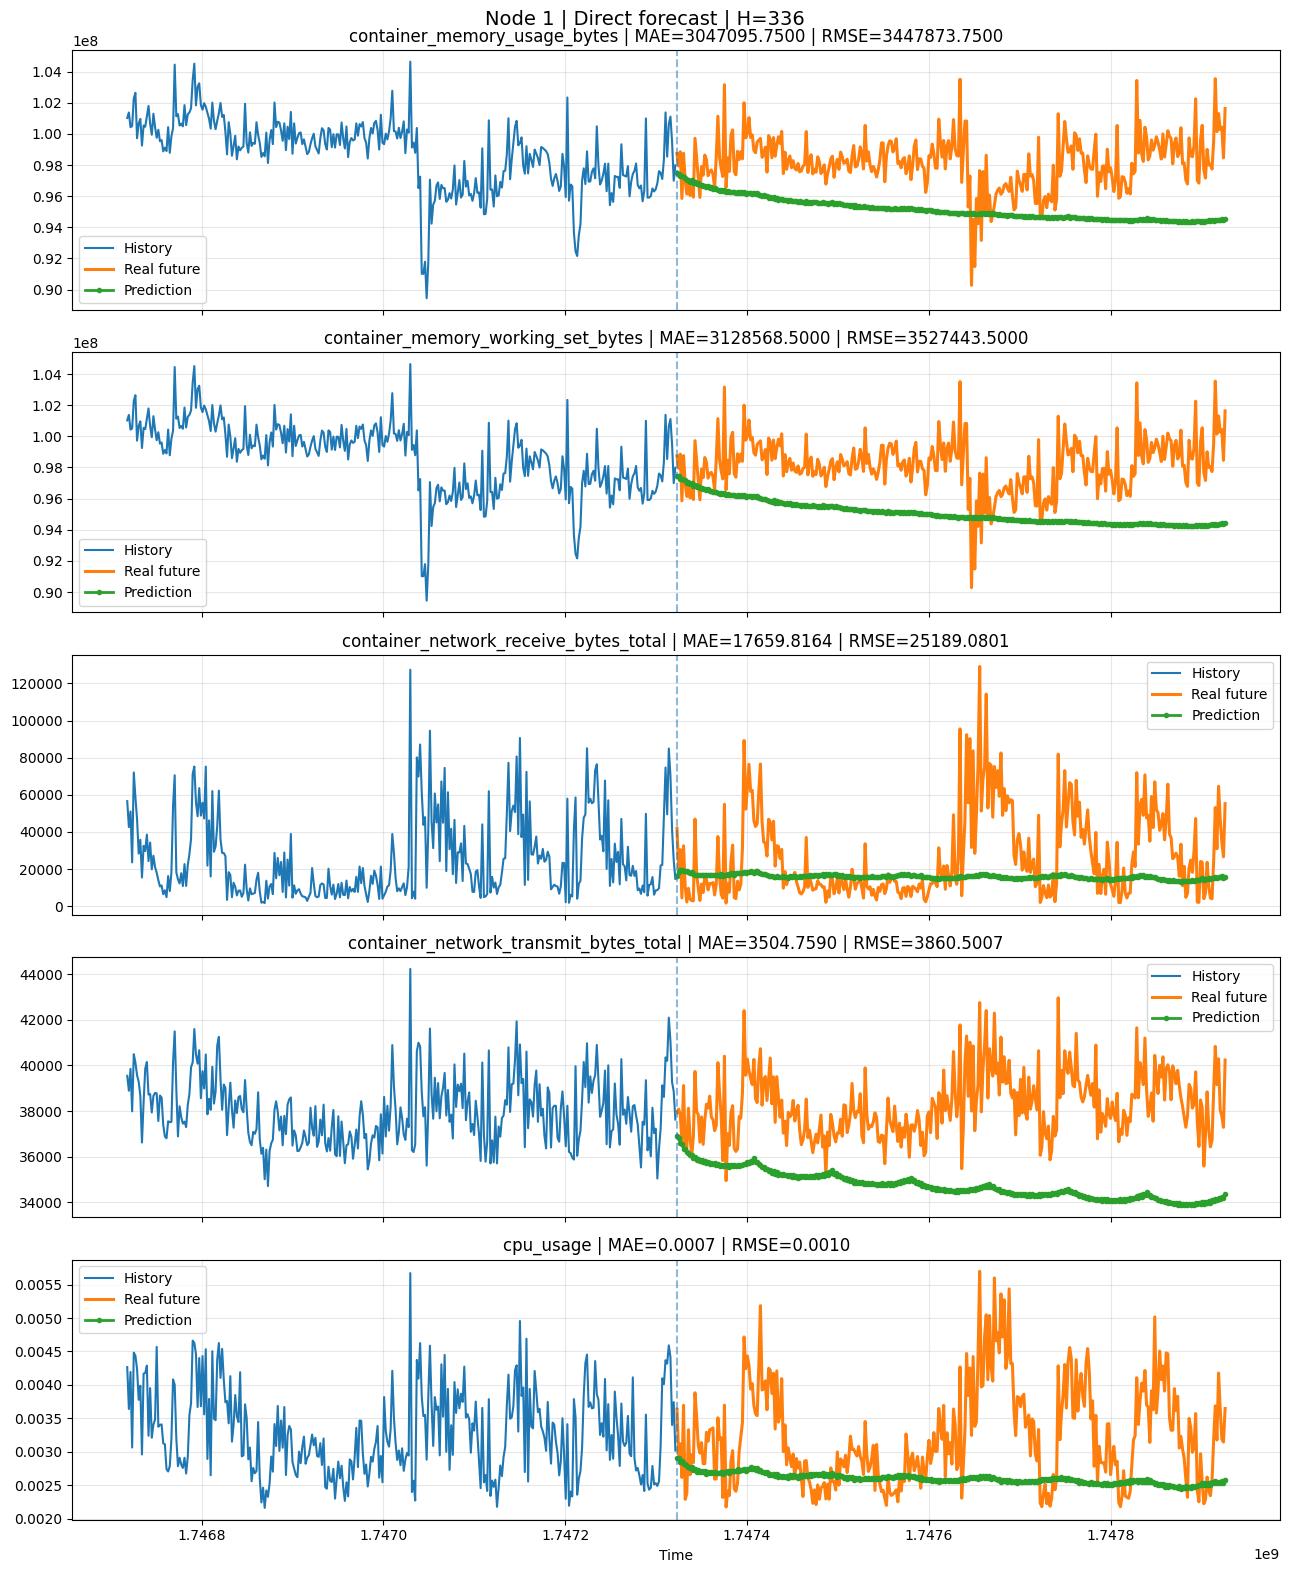

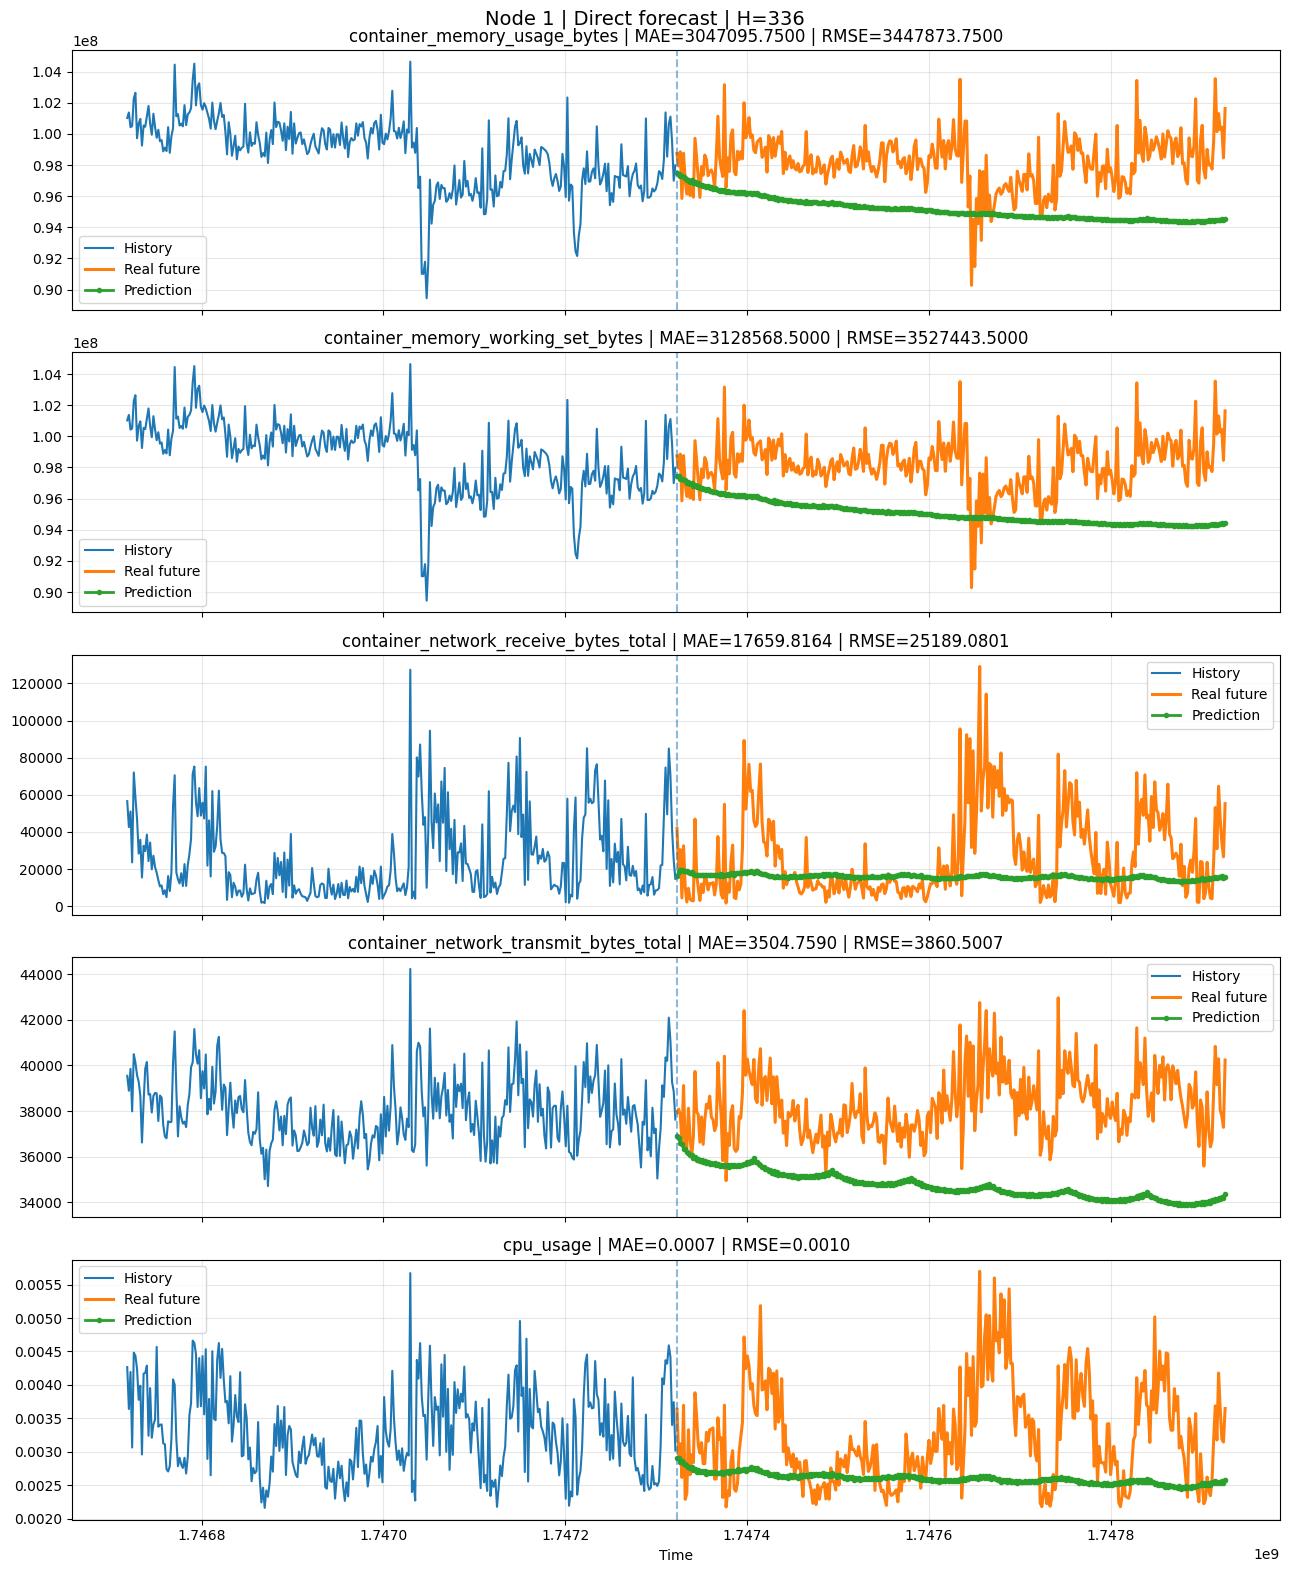

In [66]:
plot_multihorizon_forecast(
    result=result,

    node_idx=NODE_IDX,

    node_median=node_median,
    node_scale=node_scale,

    feature_names=metadata[
        "node_features"
    ],

    time_steps=metadata.get(
        "time_steps"
    ),
)

In [67]:
@torch.no_grad()
def inspect_deltas(
    model,
    loader,
    edge_index,
    device,
    n_batches=20,
):
    model.eval()

    pred_deltas = []
    true_deltas = []

    for batch_idx, batch in enumerate(loader):
        if batch_idx >= n_batches:
            break

        node_seq = batch["node_seq"].to(device)
        edge_attr = batch["edge_attr"].to(device)
        target = batch["target"].to(device)

        prediction = model(
            node_seq,
            edge_attr,
            edge_index,
        )

        # [B, 1, N, F]
        last = node_seq[:, -1].unsqueeze(1)

        pred_delta = prediction - last
        true_delta = target - last

        pred_deltas.append(
            pred_delta.cpu()
        )

        true_deltas.append(
            true_delta.cpu()
        )

    pred_deltas = torch.cat(
        pred_deltas,
        dim=0
    )

    true_deltas = torch.cat(
        true_deltas,
        dim=0
    )

    print("Pred delta mean abs:")
    print(
        pred_deltas.abs()
        .mean(dim=(0, 1, 2))
    )

    print("\nTrue delta mean abs:")
    print(
        true_deltas.abs()
        .mean(dim=(0, 1, 2))
    )

    print("\nPred delta std:")
    print(
        pred_deltas.std(
            dim=(0, 1, 2)
        )
    )

    print("\nTrue delta std:")
    print(
        true_deltas.std(
            dim=(0, 1, 2)
        )
    )

In [68]:
inspect_deltas(model, val_loader, edge_index, DEVICE)

Pred delta mean abs:
tensor([0.3107, 0.3177, 1.8136, 0.4312, 0.5661])

True delta mean abs:
tensor([0.4622, 0.4741, 3.5060, 0.8515, 1.0069])

Pred delta std:
tensor([ 0.4923,  0.5057, 25.7895,  2.9213,  2.5775])

True delta std:
tensor([ 0.8019,  0.8033, 75.5799,  6.7241,  4.5342])


In [69]:
@torch.no_grad()
def evaluate_persistence(
    loader,
    device,
):
    total_abs = None
    total_sq = None
    count = 0

    for batch in loader:

        node_seq = batch[
            "node_seq"
        ].to(device)

        target = batch[
            "target"
        ].to(device)

        # Последняя известная точка.
        #
        # [B,N,F]
        last = node_seq[:, -1]

        # ->
        # [B,H,N,F]
        persistence = (
            last
            .unsqueeze(1)
            .expand_as(target)
        )

        error = (
            persistence - target
        )

        abs_error = (
            error.abs()
            .sum(dim=(0, 2, 3))
        )

        sq_error = (
            error.square()
            .sum(dim=(0, 2, 3))
        )

        if total_abs is None:
            total_abs = abs_error
            total_sq = sq_error
        else:
            total_abs += abs_error
            total_sq += sq_error

        count += (
            error.shape[0]
            * error.shape[2]
            * error.shape[3]
        )

    mae = total_abs / count
    rmse = torch.sqrt(
        total_sq / count
    )

    return {
        "mae_by_horizon":
            mae.cpu().numpy(),

        "rmse_by_horizon":
            rmse.cpu().numpy(),
    }

In [70]:
evaluate_persistence(val_loader, DEVICE)

{'mae_by_horizon': array([0.8526808 , 0.90648425, 1.0054119 , 0.991717  , 1.0819591 ,
        1.0756478 , 1.1350883 , 1.1107653 , 1.1748275 , 1.1749736 ,
        1.2046459 , 1.1135263 , 1.2194965 , 1.2159272 , 1.237422  ,
        1.2181478 , 1.2657099 , 1.253338  , 1.2763193 , 1.2581536 ,
        1.2788683 , 1.2693049 , 1.2861636 , 1.2713267 , 1.2981726 ,
        1.2845542 , 1.308201  , 1.2780336 , 1.3114501 , 1.288769  ,
        1.3019017 , 1.2719966 , 1.2940835 , 1.2780403 , 1.2854984 ,
        1.2016069 , 1.2823141 , 1.2705638 , 1.2815771 , 1.2234071 ,
        1.2653695 , 1.2319279 , 1.2527363 , 1.1926159 , 1.2245288 ,
        1.1876599 , 1.1856833 , 1.0283986 , 1.189434  , 1.1947861 ,
        1.2369566 , 1.2117643 , 1.2741648 , 1.2634213 , 1.2917848 ,
        1.2610215 , 1.317106  , 1.3085423 , 1.3330243 , 1.2706298 ,
        1.3428451 , 1.3285203 , 1.355325  , 1.3307148 , 1.3631337 ,
        1.3558128 , 1.3744745 , 1.3571267 , 1.3803132 , 1.3654606 ,
        1.3810171 , 1.3623742 